# Week 5 (Day 18) — Notebook 02
## Advanced Clustering Algorithms (Hierarchical, DBSCAN, GMM)

This notebook covers:
- Dataset scenarios: blobs, moons, circles, plus mixed-type Nigerian customer data
- Baseline K-Means reproduction + internal metrics
- Hierarchical clustering (linkage variants) + dendrogram cutting
- DBSCAN parameter sweep + noise handling
- Gaussian Mixture Models (soft clustering) + AIC/BIC selection
- Comparative analysis (quant + visual)

> Reminder: clustering is **unsupervised**. If a dataset has labels, use them only for sanity checks—not for training.

In [1]:
# Setup: imports, settings, and helper utilities
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def safe_internal_metrics(X, labels):
    """Compute internal clustering metrics when valid.

    Returns dict with silhouette, davies_bouldin, calinski_harabasz.
    Uses NaN when a metric is undefined.
    """
    metrics = {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}

    labels = np.asarray(labels)

    # DBSCAN uses -1 for noise; metrics still require >=2 clusters among non-noise points
    non_noise_mask = labels != -1
    labels_non_noise = labels[non_noise_mask]

    if len(np.unique(labels_non_noise)) < 2:
        return metrics

    if hasattr(X, "toarray"):
        X_dense = X.toarray()
        X_eval = X_dense[non_noise_mask]
    else:
        X_eval = X[non_noise_mask]

    try:
        metrics["silhouette"] = float(silhouette_score(X_eval, labels_non_noise))
    except Exception:
        pass

    try:
        metrics["davies_bouldin"] = float(davies_bouldin_score(X_eval, labels_non_noise))
    except Exception:
        pass

    try:
        metrics["calinski_harabasz"] = float(calinski_harabasz_score(X_eval, labels_non_noise))
    except Exception:
        pass

    return metrics


def pca_2d(X):
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    return PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dense)


def plot_2d(X, labels, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
        _ = fig

    emb = pca_2d(X)
    labels = np.asarray(labels)

    uniq = np.unique(labels)
    for lab in uniq:
        mask = labels == lab
        if lab == -1:
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.75, c="gray", label="noise (-1)")
        else:
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.85, label=str(lab))

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")


def run_kmeans(X, k=4, n_init=10):
    start = time.time()
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=n_init)
    labels = model.fit_predict(X)
    runtime_s = time.time() - start

    out = {
        "model": "kmeans",
        "params": {"k": k},
        "labels": labels,
        "runtime_s": runtime_s,
        "inertia": float(getattr(model, "inertia_", np.nan)),
    }
    out.update(safe_internal_metrics(X, labels))
    return out


def _make_agglomerative(n_clusters, linkage):
    """Compatibility helper for sklearn versions (metric vs affinity)."""
    try:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric="euclidean")
    except TypeError:
        # older sklearn
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, affinity="euclidean")  # type: ignore[call-arg]


def run_agglomerative(X, k=4, linkage="ward"):
    start = time.time()
    model = _make_agglomerative(n_clusters=k, linkage=linkage)
    labels = model.fit_predict(X)
    runtime_s = time.time() - start

    out = {
        "model": "agglomerative",
        "params": {"k": k, "linkage": linkage},
        "labels": labels,
        "runtime_s": runtime_s,
        "inertia": np.nan,
    }
    out.update(safe_internal_metrics(X, labels))
    return out


def run_dbscan(X, eps=0.3, min_samples=5):
    start = time.time()
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    runtime_s = time.time() - start

    labels_arr = np.asarray(labels)
    n_clusters = len(set(labels_arr)) - (1 if -1 in labels_arr else 0)
    noise_frac = float(np.mean(labels_arr == -1))

    out = {
        "model": "dbscan",
        "params": {"eps": eps, "min_samples": min_samples},
        "labels": labels,
        "runtime_s": runtime_s,
        "inertia": np.nan,
        "n_clusters": int(n_clusters),
        "noise_frac": noise_frac,
    }
    out.update(safe_internal_metrics(X, labels))
    return out


def run_gmm(X, n_components=4, covariance_type="full"):
    X_dense = X.toarray() if hasattr(X, "toarray") else X

    start = time.time()
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_dense)
    runtime_s = time.time() - start

    out = {
        "model": "gmm",
        "params": {"n_components": n_components, "covariance_type": covariance_type},
        "labels": labels,
        "runtime_s": runtime_s,
        "inertia": np.nan,
        "aic": float(model.aic(X_dense)),
        "bic": float(model.bic(X_dense)),
        "max_prob_mean": float(np.mean(np.max(model.predict_proba(X_dense), axis=1))),
    }
    out.update(safe_internal_metrics(X_dense, labels))
    return out


print("Setup complete.")

Setup complete.


## Load/generate datasets for clustering scenarios
We’ll compare algorithms on:
- **Blobs** (roughly spherical clusters → K-Means often works)
- **Moons/Circles** (non-spherical clusters → DBSCAN often shines)
- **Mixed tabular dataset** (Nigerian customer segmentation → needs preprocessing)

If you have a project dataset, you can plug its CSV path in the loader cell.

In [2]:
def load_project_csv(path: str | None):
    if not path:
        return None
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"CSV not found: {p}")
    return pd.read_csv(p)


def make_synthetic_datasets(n=500, random_state=RANDOM_STATE):
    X_blobs, _ = make_blobs(n_samples=n, centers=4, cluster_std=1.1, random_state=random_state)
    X_moons, _ = make_moons(n_samples=n, noise=0.08, random_state=random_state)
    X_circles, _ = make_circles(n_samples=n, noise=0.06, factor=0.5, random_state=random_state)

    return {
        "blobs": X_blobs,
        "moons": X_moons,
        "circles": X_circles,
    }


# (A) Synthetic datasets
synthetic = make_synthetic_datasets(n=600)
for name, X in synthetic.items():
    print(name, X.shape)

# (B) Mixed-type tabular dataset (course-provided)
customer_path = Path("nigerian_customer_segments.csv")
if not customer_path.exists():
    customer_path = Path("Materials") / "Week 5" / "nigerian_customer_segments.csv"

customer_df = pd.read_csv(customer_path)
print("customer_df:", customer_df.shape)
customer_df.head()

blobs (600, 2)
moons (600, 2)
circles (600, 2)
customer_df: (40, 15)


,customer_id,state,age,gender,employment_type,monthly_income_ngn,avg_monthly_spend_ngn,online_purchases_last_30d,store_visits_last_30d,tenure_months,smartphone,preferred_channel,has_bank_account,late_payments_last_12m,segment_hint
0,CUST0001,Lagos,28,F,private,420000,180000,12,2,18,yes,online,yes,0,digital_affluent
1,CUST0002,Lagos,34,M,private,520000,240000,15,1,26,yes,online,yes,1,digital_affluent
2,CUST0003,Abuja,31,F,private,380000,160000,10,3,20,yes,online,yes,0,digital_affluent
3,CUST0004,Rivers,29,M,private,450000,190000,11,2,15,yes,online,yes,0,digital_affluent
4,CUST0005,Oyo,36,F,private,600000,260000,16,2,32,yes,online,yes,0,digital_affluent


## Review: K-Means baseline (synthetic blobs)
We start with a dataset where K-Means is expected to perform well (roughly spherical clusters).

In [3]:
X_blobs = synthetic["blobs"]

kmeans_blobs = run_kmeans(X_blobs, k=4)

pd.DataFrame([
    {
        "dataset": "blobs",
        "model": kmeans_blobs["model"],
        "params": kmeans_blobs["params"],
        "silhouette": kmeans_blobs["silhouette"],
        "davies_bouldin": kmeans_blobs["davies_bouldin"],
        "calinski_harabasz": kmeans_blobs["calinski_harabasz"],
        "runtime_s": kmeans_blobs["runtime_s"],
        "inertia": kmeans_blobs["inertia"],
    }
])

,dataset,model,params,silhouette,davies_bouldin,calinski_harabasz,runtime_s,inertia
0,blobs,kmeans,{'k': 4},0.766994,0.329111,5461.273383,0.118071,1400.091622


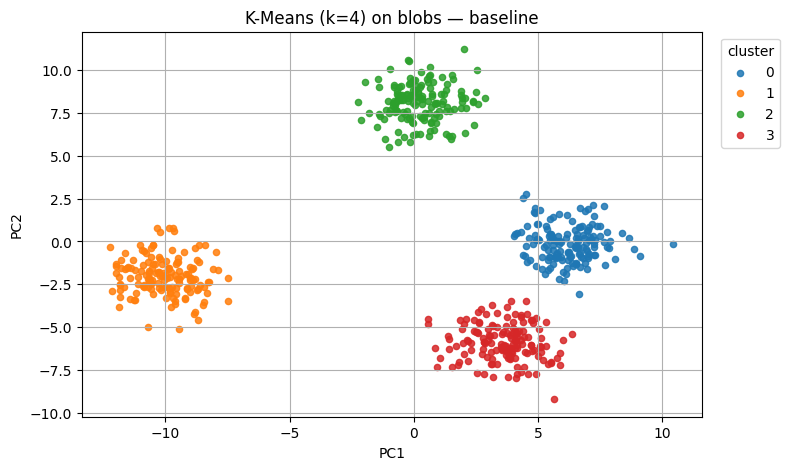

In [4]:
fig, ax = plt.subplots()
plot_2d(X_blobs, kmeans_blobs["labels"], title="K-Means (k=4) on blobs — baseline", ax=ax)
plt.show()

## Feature preprocessing: scaling demo (synthetic blobs)
Even on blobs, scaling can matter if features have different ranges.

We’ll artificially stretch one axis and see how scaling fixes it.

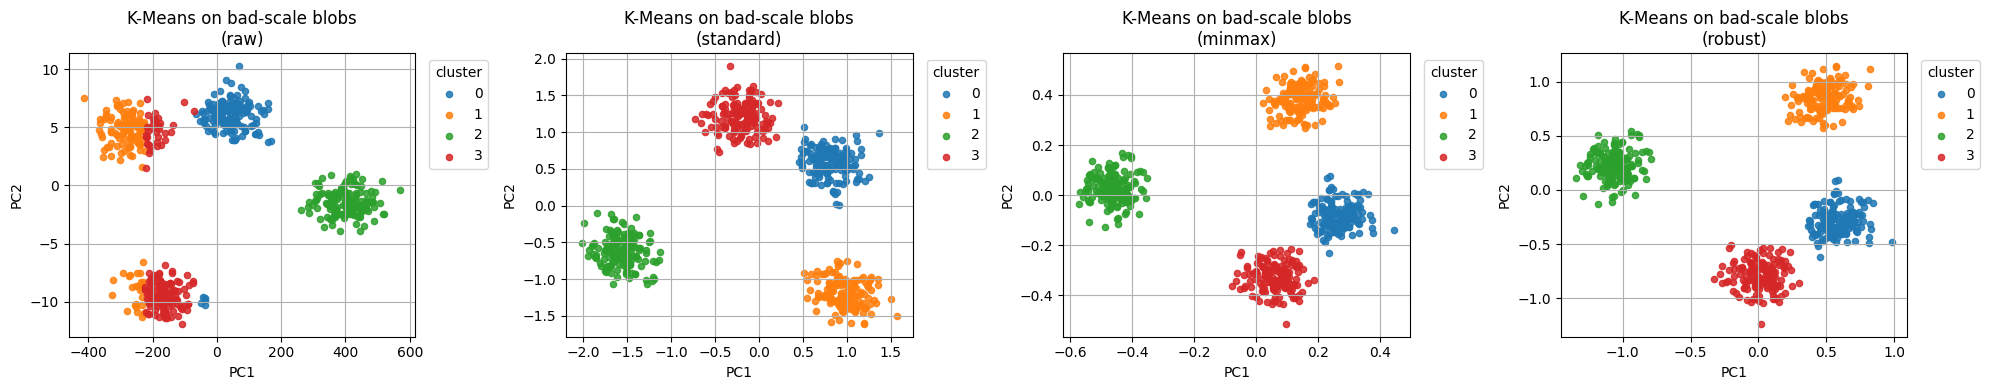

,preprocess,silhouette,davies_bouldin,runtime_s,inertia
1,standard,0.774077,0.316890,0.096780,4.309144e+01
3,robust,0.773430,0.318091,0.092083,1.782166e+01
2,minmax,0.772626,0.319561,0.076130,3.193066e+00
0,raw,0.659459,0.430498,0.013573,1.271453e+06


In [5]:
# Create a "badly scaled" version of blobs
X_blobs_bad = X_blobs.copy()
X_blobs_bad[:, 0] = X_blobs_bad[:, 0] * 50.0  # stretch x-axis

scalers = {
    "raw": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

rows = []
fig, axes = plt.subplots(1, len(scalers), figsize=(20, 4))

for ax, (name, scaler) in zip(axes, scalers.items()):
    X_use = X_blobs_bad
    if scaler is not None:
        X_use = scaler.fit_transform(X_use)

    out = run_kmeans(X_use, k=4)
    rows.append(
        {
            "preprocess": name,
            "silhouette": out.get("silhouette"),
            "davies_bouldin": out.get("davies_bouldin"),
            "runtime_s": out.get("runtime_s"),
            "inertia": out.get("inertia"),
        }
    )

    plot_2d(X_use, out["labels"], title=f"K-Means on bad-scale blobs\n({name})", ax=ax)

plt.tight_layout()
plt.show()

pd.DataFrame(rows).sort_values("silhouette", ascending=False)

## Mixed data preprocessing (customer dataset)
We’ll build a single preprocessing pipeline:
- numeric: median impute + scale
- categorical: most-frequent impute + one-hot

Then all clustering algorithms can consume the same feature matrix.

In [6]:
# Separate features (ignore identifiers + segment hint)
id_col = "customer_id"
hint_col = "segment_hint"

customer_features = customer_df.drop(columns=[c for c in [id_col, hint_col] if c in customer_df.columns])

num_cols = customer_features.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in customer_features.columns if c not in num_cols]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

customer_preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

X_customer = customer_preprocess.fit_transform(customer_features)
print("X_customer shape:", X_customer.shape)

Numeric: ['age', 'monthly_income_ngn', 'avg_monthly_spend_ngn', 'online_purchases_last_30d', 'store_visits_last_30d', 'tenure_months', 'late_payments_last_12m']
Categorical: ['state', 'gender', 'employment_type', 'smartphone', 'preferred_channel', 'has_bank_account']
X_customer shape: (40, 40)


## Hierarchical clustering (Agglomerative) + linkage variants
We’ll try multiple linkage strategies and compare internal metrics.

Notes:
- Ward linkage typically performs well for compact, Euclidean clusters.
- Ward requires Euclidean distance and numeric feature space (we’re using scaled numeric + one-hot here).

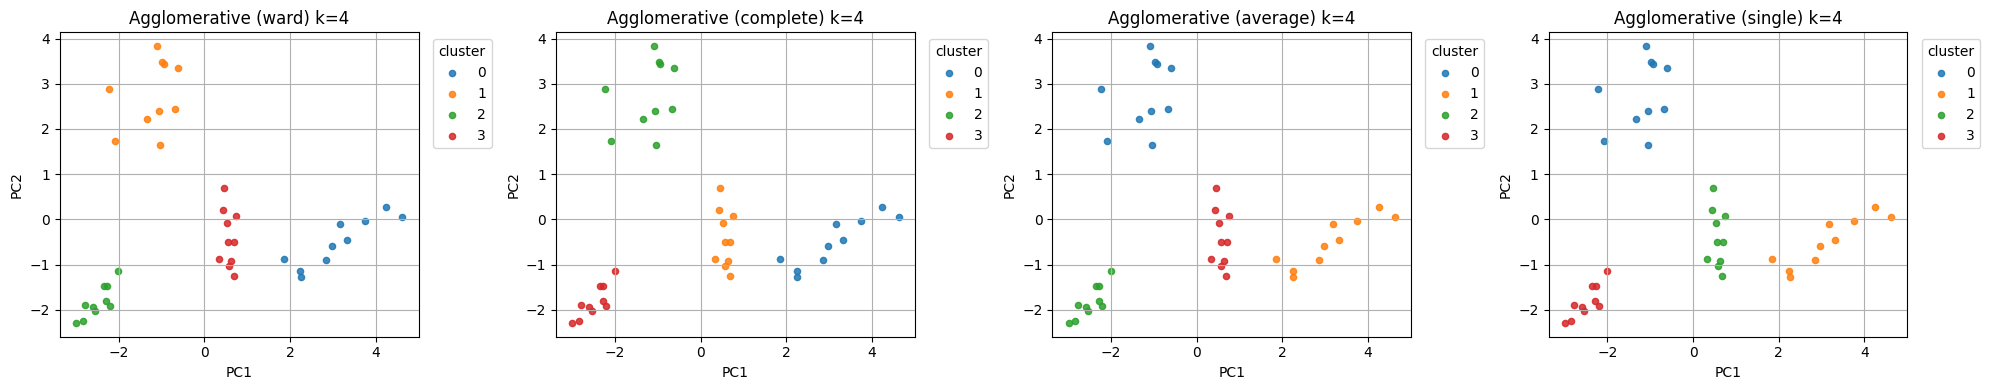

,linkage,k,silhouette,davies_bouldin,calinski_harabasz,runtime_s
0,ward,4,0.468592,0.791713,39.960937,0.026273
1,complete,4,0.468592,0.791713,39.960937,0.000645
2,average,4,0.468592,0.791713,39.960937,0.000520
3,single,4,0.468592,0.791713,39.960937,0.000492


In [7]:
k = 4
linkages = ["ward", "complete", "average", "single"]

agg_rows = []
fig, axes = plt.subplots(1, len(linkages), figsize=(20, 4))

for ax, link in zip(axes, linkages):
    try:
        out = run_agglomerative(X_customer, k=k, linkage=link)
    except Exception as e:
        agg_rows.append({"linkage": link, "error": str(e)})
        ax.set_title(f"{link} (error)")
        ax.axis("off")
        continue

    agg_rows.append(
        {
            "linkage": link,
            "k": k,
            "silhouette": out["silhouette"],
            "davies_bouldin": out["davies_bouldin"],
            "calinski_harabasz": out["calinski_harabasz"],
            "runtime_s": out["runtime_s"],
        }
    )
    plot_2d(X_customer, out["labels"], title=f"Agglomerative ({link}) k={k}", ax=ax)

plt.tight_layout()
plt.show()

pd.DataFrame(agg_rows).sort_values("silhouette", ascending=False)

## Hierarchical clustering: dendrogram + cutting the tree
For a dendrogram, we typically need SciPy.

If SciPy is unavailable, you can skip this section and rely on `AgglomerativeClustering` results.

We’ll build a dendrogram using a **subsample** (dendrograms get expensive as n grows).

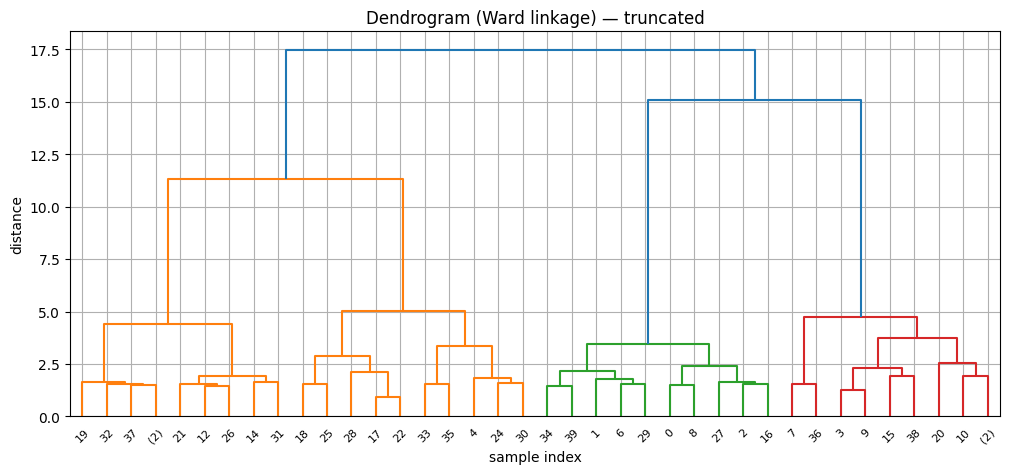

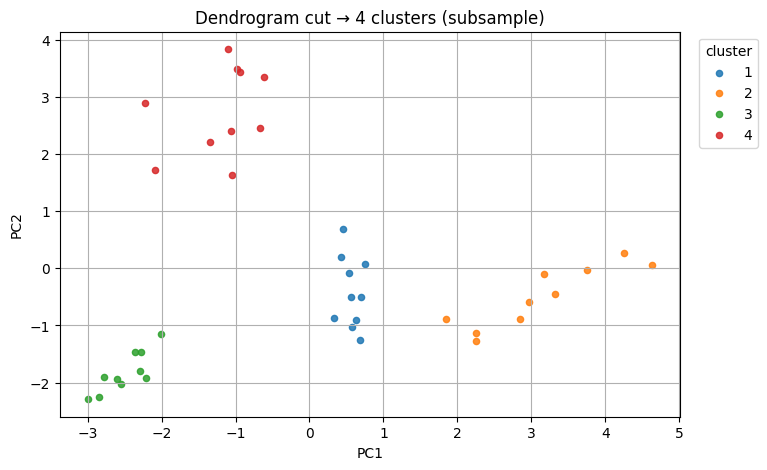

In [8]:
# Dendrogram construction (SciPy)
try:
    from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

    X_dense = X_customer.toarray() if hasattr(X_customer, "toarray") else X_customer

    # Subsample for readability and performance
    n_sample = min(60, X_dense.shape[0])
    idx = np.random.choice(np.arange(X_dense.shape[0]), size=n_sample, replace=False)
    X_sub = X_dense[idx]

    Z = linkage(X_sub, method="ward")

    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode="level", p=5)
    plt.title("Dendrogram (Ward linkage) — truncated")
    plt.xlabel("sample index")
    plt.ylabel("distance")
    plt.show()

    # Cut the tree into k clusters
    k_cut = 4
    labels_cut = fcluster(Z, t=k_cut, criterion="maxclust")

    fig, ax = plt.subplots()
    plot_2d(X_sub, labels_cut, title=f"Dendrogram cut → {k_cut} clusters (subsample)", ax=ax)
    plt.show()

except Exception as e:
    print("SciPy dendrogram section skipped:", e)

## DBSCAN: density-based clustering + parameter sweep
DBSCAN can:
- discover **non-spherical** clusters
- label **noise/outliers** as `-1`

We’ll use moons/circles and sweep `eps` and `min_samples`.

Tip: scaling is critical for DBSCAN.

Moons/circles shapes: (600, 2) (600, 2)


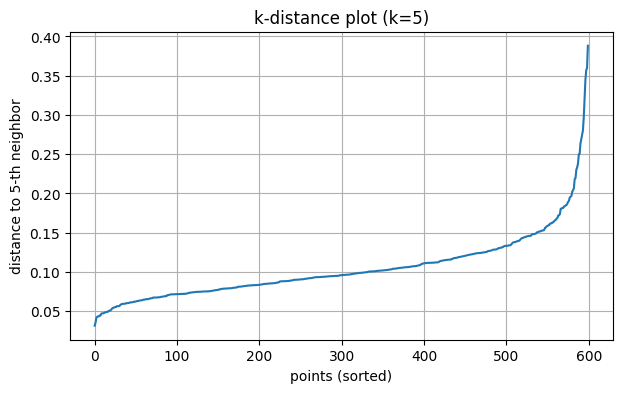

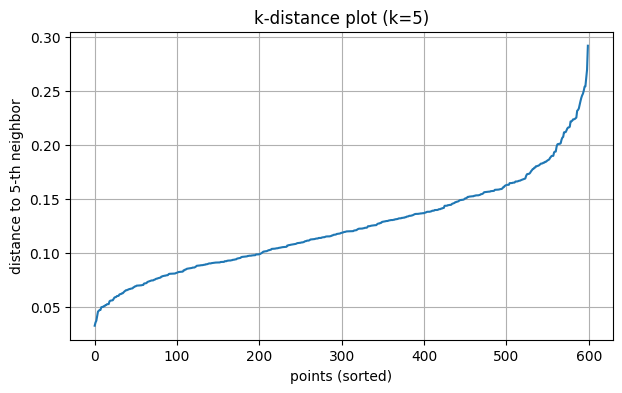

In [9]:
X_moons = synthetic["moons"]
X_circles = synthetic["circles"]

# Scale for DBSCAN (important)
scaler = StandardScaler()
X_moons_s = scaler.fit_transform(X_moons)
X_circles_s = scaler.fit_transform(X_circles)


def k_distance_plot(X, k=5):
    """Plot sorted distance to k-th nearest neighbor (helps pick eps)."""
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    k_dist = np.sort(distances[:, -1])

    plt.figure(figsize=(7, 4))
    plt.plot(k_dist)
    plt.title(f"k-distance plot (k={k})")
    plt.xlabel("points (sorted)")
    plt.ylabel(f"distance to {k}-th neighbor")
    plt.show()


print("Moons/circles shapes:", X_moons.shape, X_circles.shape)

k_distance_plot(X_moons_s, k=5)
k_distance_plot(X_circles_s, k=5)


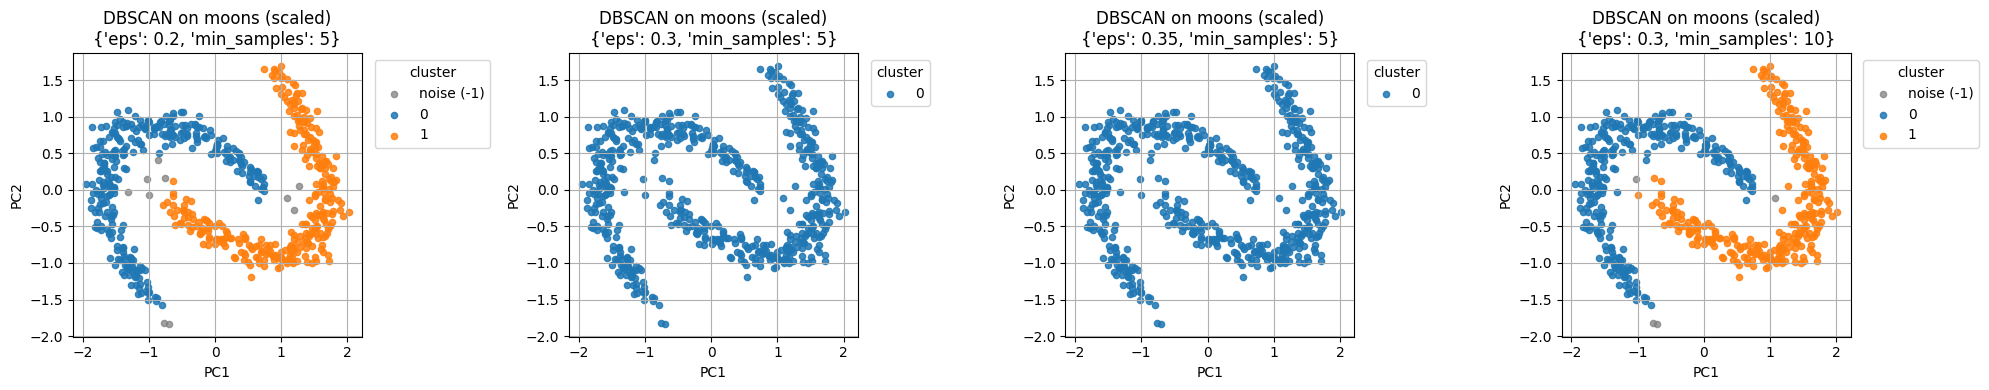

,eps,min_samples,n_clusters,noise_frac,silhouette,davies_bouldin
0,0.20,5,2,0.016667,0.39164,1.009618
3,0.30,10,2,0.006667,0.38873,1.013782
1,0.30,5,1,0.000000,NaN,NaN
2,0.35,5,1,0.000000,NaN,NaN


In [10]:
# Parameter sweep (keep small for class time)
param_grid = [
    {"eps": 0.2, "min_samples": 5},
    {"eps": 0.3, "min_samples": 5},
    {"eps": 0.35, "min_samples": 5},
    {"eps": 0.3, "min_samples": 10},
]


def sweep_dbscan(X, title_prefix):
    rows = []
    fig, axes = plt.subplots(1, len(param_grid), figsize=(20, 4))

    for ax, params in zip(axes, param_grid):
        out = run_dbscan(X, **params)
        rows.append(
            {
                "eps": params["eps"],
                "min_samples": params["min_samples"],
                "n_clusters": out["n_clusters"],
                "noise_frac": out["noise_frac"],
                "silhouette": out["silhouette"],
                "davies_bouldin": out["davies_bouldin"],
            }
        )
        plot_2d(X, out["labels"], title=f"{title_prefix}\n{params}", ax=ax)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows).sort_values(["silhouette", "noise_frac"], ascending=[False, True])


dbscan_moons = sweep_dbscan(X_moons_s, "DBSCAN on moons (scaled)")
dbscan_moons

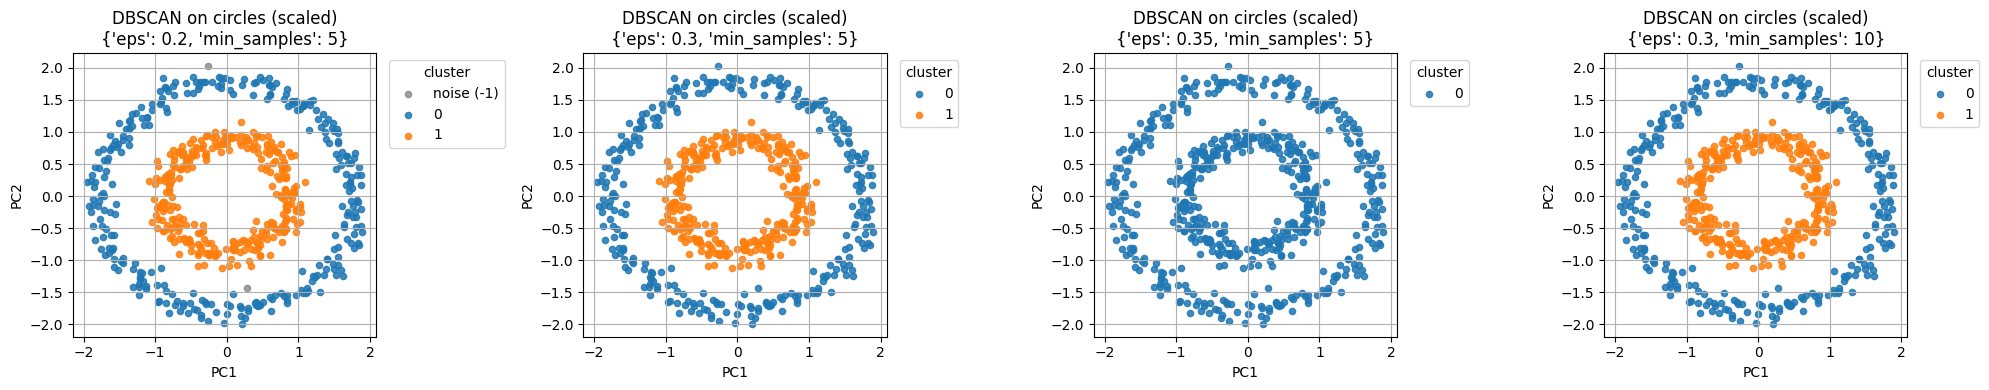

,eps,min_samples,n_clusters,noise_frac,silhouette,davies_bouldin
0,0.20,5,2,0.003333,0.114058,631.763286
1,0.30,5,2,0.000000,0.113039,1034.919807
3,0.30,10,2,0.000000,0.113039,1034.919807
2,0.35,5,1,0.000000,NaN,NaN


In [11]:
dbscan_circles = sweep_dbscan(X_circles_s, "DBSCAN on circles (scaled)")
dbscan_circles

## Gaussian Mixture Models (GMM): soft clustering + probabilities
GMM returns:
- hard labels via `predict()`
- soft membership probabilities via `predict_proba()`

We’ll select the number of components using AIC/BIC and visualize uncertainty.

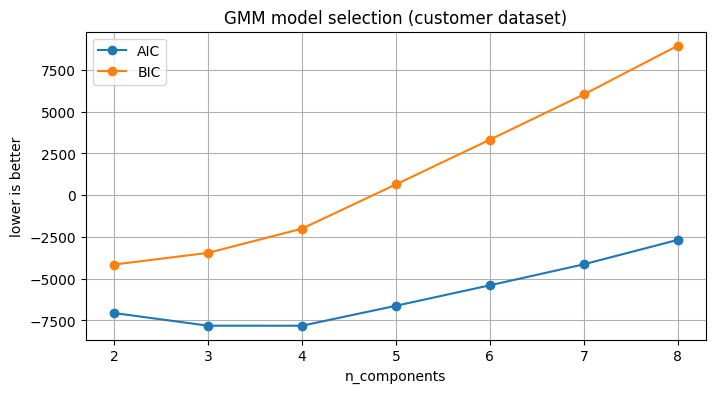

Best n_components by BIC: 2


In [12]:
# GMM on customer dataset (dense required)
X_cust_dense = X_customer.toarray() if hasattr(X_customer, "toarray") else X_customer

components = list(range(2, 9))
aic_vals = []
bic_vals = []

for c in components:
    out = run_gmm(X_cust_dense, n_components=c, covariance_type="full")
    aic_vals.append(out["aic"])
    bic_vals.append(out["bic"])

plt.figure(figsize=(8, 4))
plt.plot(components, aic_vals, marker="o", label="AIC")
plt.plot(components, bic_vals, marker="o", label="BIC")
plt.title("GMM model selection (customer dataset)")
plt.xlabel("n_components")
plt.ylabel("lower is better")
plt.legend()
plt.show()

best_c = components[int(np.argmin(bic_vals))]
print("Best n_components by BIC:", best_c)

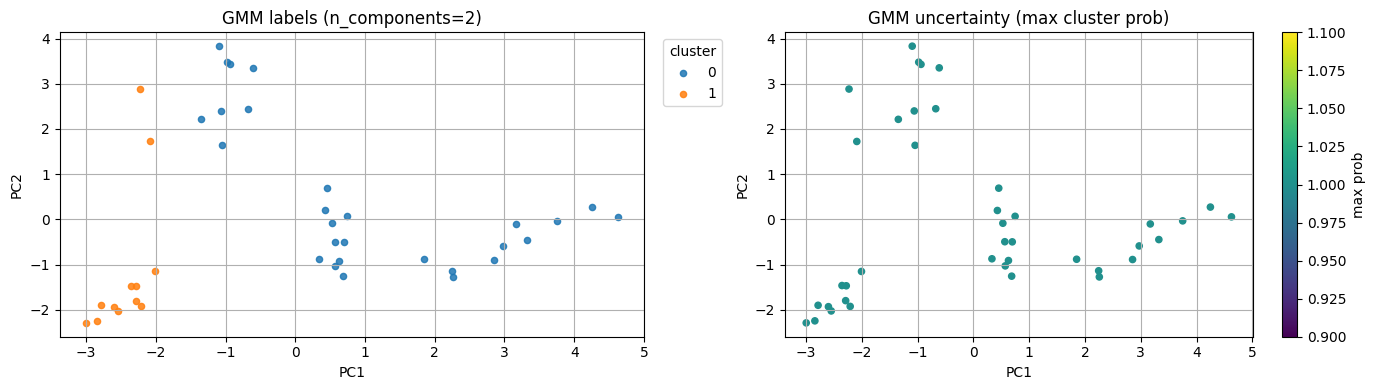

,model,n_components,silhouette,davies_bouldin,aic,bic,max_prob_mean,runtime_s
0,gmm,2,0.298514,1.214916,-7058.265229,-4151.703689,1.0,0.047652


In [13]:
# Fit best GMM and visualize labels + uncertainty
best_gmm_out = run_gmm(X_cust_dense, n_components=best_c, covariance_type="full")

# For uncertainty: mean of max prob already computed, but let's plot per-point max prob
model = GaussianMixture(
    n_components=best_c,
    covariance_type="full",
    random_state=RANDOM_STATE,
).fit(X_cust_dense)

probs = model.predict_proba(X_cust_dense)
max_prob = np.max(probs, axis=1)
labels = model.predict(X_cust_dense)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_2d(X_cust_dense, labels, title=f"GMM labels (n_components={best_c})", ax=axes[0])

emb = pca_2d(X_cust_dense)
sc = axes[1].scatter(emb[:, 0], emb[:, 1], c=max_prob, cmap="viridis", s=20)
axes[1].set_title("GMM uncertainty (max cluster prob)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="max prob")

plt.tight_layout()
plt.show()

pd.DataFrame([
    {
        "model": "gmm",
        "n_components": best_c,
        "silhouette": best_gmm_out["silhouette"],
        "davies_bouldin": best_gmm_out["davies_bouldin"],
        "aic": best_gmm_out["aic"],
        "bic": best_gmm_out["bic"],
        "max_prob_mean": best_gmm_out["max_prob_mean"],
        "runtime_s": best_gmm_out["runtime_s"],
    }
])

## Comparative analysis: when to use which (customer dataset)
We’ll run:
- K-Means (baseline)
- Agglomerative (best linkage from earlier)
- DBSCAN (with a couple of parameter candidates)
- GMM (best by BIC)

Then we’ll summarize in a comparison table.

In [14]:
# Pick best linkage from agg_rows table (ignoring errors)
agg_df = pd.DataFrame(agg_rows)
agg_df_ok = agg_df.dropna(subset=["silhouette"]).copy()
best_linkage = agg_df_ok.sort_values("silhouette", ascending=False).iloc[0]["linkage"] if len(agg_df_ok) else "ward"
print("Best linkage by silhouette:", best_linkage)

comparison_rows = []

# K-Means
km_out = run_kmeans(X_customer, k=4)
comparison_rows.append(
    {
        "algorithm": "kmeans",
        "params": km_out["params"],
        "silhouette": km_out["silhouette"],
        "davies_bouldin": km_out["davies_bouldin"],
        "calinski_harabasz": km_out["calinski_harabasz"],
        "n_clusters": 4,
        "noise_frac": 0.0,
        "runtime_s": km_out["runtime_s"],
    }
)

# Agglomerative
agg_out = run_agglomerative(X_customer, k=4, linkage=best_linkage)
comparison_rows.append(
    {
        "algorithm": f"agglomerative_{best_linkage}",
        "params": agg_out["params"],
        "silhouette": agg_out["silhouette"],
        "davies_bouldin": agg_out["davies_bouldin"],
        "calinski_harabasz": agg_out["calinski_harabasz"],
        "n_clusters": 4,
        "noise_frac": 0.0,
        "runtime_s": agg_out["runtime_s"],
    }
)

# DBSCAN (two quick tries)
# NOTE: These eps values are only a starting point; tune in practice.
db1 = run_dbscan(X_customer, eps=0.9, min_samples=5)
db2 = run_dbscan(X_customer, eps=1.2, min_samples=5)

for out in [db1, db2]:
    comparison_rows.append(
        {
            "algorithm": "dbscan",
            "params": out["params"],
            "silhouette": out["silhouette"],
            "davies_bouldin": out["davies_bouldin"],
            "calinski_harabasz": out["calinski_harabasz"],
            "n_clusters": out["n_clusters"],
            "noise_frac": out["noise_frac"],
            "runtime_s": out["runtime_s"],
        }
    )

# GMM (best by BIC already computed)
gmm_out = best_gmm_out
comparison_rows.append(
    {
        "algorithm": "gmm",
        "params": gmm_out["params"],
        "silhouette": gmm_out["silhouette"],
        "davies_bouldin": gmm_out["davies_bouldin"],
        "calinski_harabasz": gmm_out["calinski_harabasz"],
        "n_clusters": best_c,
        "noise_frac": 0.0,
        "runtime_s": gmm_out["runtime_s"],
        "aic": gmm_out.get("aic"),
        "bic": gmm_out.get("bic"),
    }
)

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])

Best linkage by silhouette: ward


,algorithm,params,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,runtime_s,aic,bic
0,kmeans,{'k': 4},0.468592,0.791713,39.960937,4,0.0,0.008246,NaN,NaN
1,agglomerative_ward,"{'k': 4, 'linkage': 'ward'}",0.468592,0.791713,39.960937,4,0.0,0.000605,NaN,NaN
4,gmm,"{'n_components': 2, 'covariance_type': 'full'}",0.298514,1.214916,16.731431,2,0.0,0.047652,-7058.265229,-4151.703689
2,dbscan,"{'eps': 0.9, 'min_samples': 5}",NaN,NaN,NaN,0,1.0,0.000782,NaN,NaN
3,dbscan,"{'eps': 1.2, 'min_samples': 5}",NaN,NaN,NaN,0,1.0,0.000558,NaN,NaN


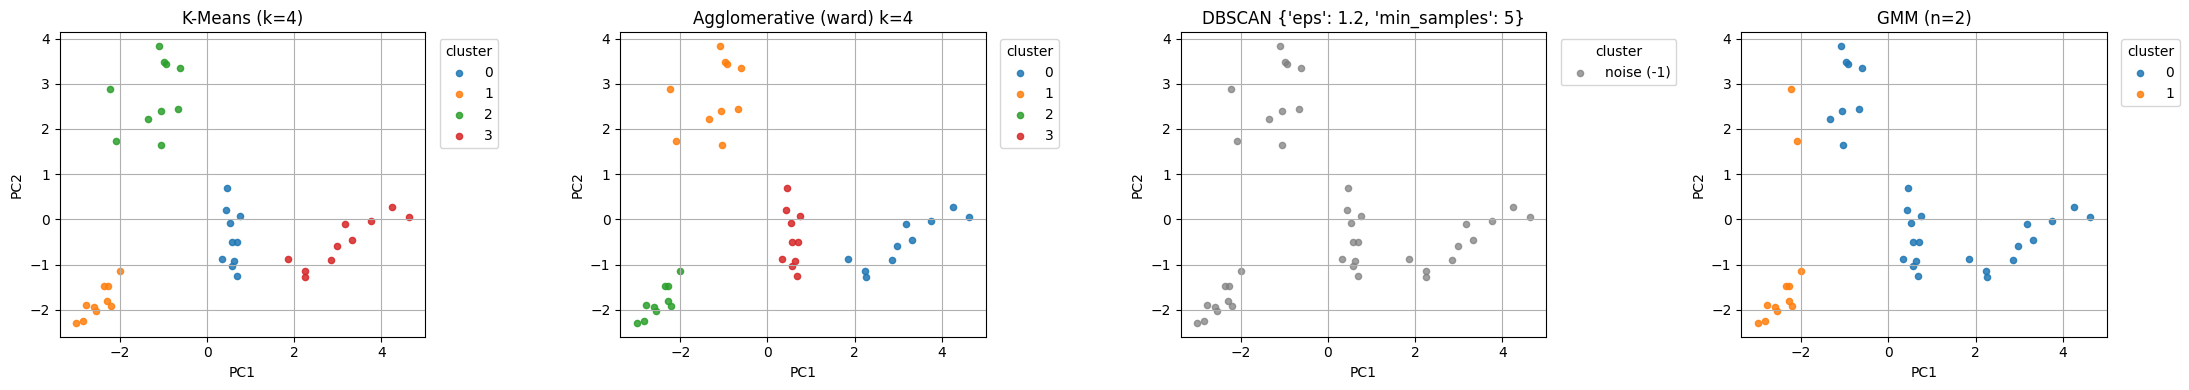

In [15]:
# Side-by-side visualization on customer dataset
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

plot_2d(X_customer, km_out["labels"], title="K-Means (k=4)", ax=axes[0])
plot_2d(X_customer, agg_out["labels"], title=f"Agglomerative ({best_linkage}) k=4", ax=axes[1])
plot_2d(X_customer, db2["labels"], title=f"DBSCAN {db2['params']}", ax=axes[2])
plot_2d(X_cust_dense, labels, title=f"GMM (n={best_c})", ax=axes[3])

plt.tight_layout()
plt.show()

## Cluster visualization: PCA (default) + optional UMAP
PCA is fast and good for debugging.

UMAP can sometimes reveal nonlinear structure (optional; only if installed).

In [16]:
# Optional UMAP visualization (if installed)
try:
    import umap

    X_dense = X_customer.toarray() if hasattr(X_customer, "toarray") else X_customer
    embedding = umap.UMAP(random_state=RANDOM_STATE).fit_transform(X_dense)

    plt.figure(figsize=(7, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=km_out["labels"], s=20, alpha=0.85)
    plt.title("UMAP projection (colored by K-Means labels)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.show()

except Exception as e:
    print("UMAP not available (skipping):", e)

UMAP not available (skipping): No module named 'umap'


## Practice lab (choose a dataset + tune one parameter)
Pick one dataset: `blobs`, `moons`, `circles`, or the customer dataset.

Tasks:
1) Run K-Means with 2 different `k` values.
2) Run Agglomerative with 2 linkages.
3) Run DBSCAN and tune either `eps` or `min_samples`.
4) Run GMM and change `n_components`.
5) Record the best configuration (silhouette + sanity-check the plot).

In [17]:
# Practice cell: pick a dataset and run multiple algorithms

dataset_choice = "moons"  # choose: 'blobs', 'moons', 'circles', 'customer'

if dataset_choice in ["blobs", "moons", "circles"]:
    X = synthetic[dataset_choice]
    X = StandardScaler().fit_transform(X)
else:
    X = X_customer

runs = []

# K-Means (try 2 k values)
for k_try in [3, 4]:
    out = run_kmeans(X, k=k_try)
    runs.append({"algorithm": "kmeans", "params": out["params"], **{k: out.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}})

# Agglomerative (try 2 linkages)
for link in ["ward", "complete"]:
    try:
        out = run_agglomerative(X, k=4, linkage=link)
        runs.append({"algorithm": "agglomerative", "params": out["params"], **{k: out.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}})
    except Exception as e:
        runs.append({"algorithm": "agglomerative", "params": {"linkage": link}, "error": str(e)})

# DBSCAN (tune eps)
for eps in [0.2, 0.3, 0.4]:
    out = run_dbscan(X, eps=eps, min_samples=5)
    runs.append({"algorithm": "dbscan", "params": out["params"], "n_clusters": out.get("n_clusters"), "noise_frac": out.get("noise_frac"), **{k: out.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}})

# GMM (only for dense)
X_dense = X.toarray() if hasattr(X, "toarray") else X
for c in [3, 4, 5]:
    out = run_gmm(X_dense, n_components=c)
    runs.append({"algorithm": "gmm", "params": out["params"], "bic": out.get("bic"), "aic": out.get("aic"), **{k: out.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}})

runs_df = pd.DataFrame(runs)
runs_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).head(10)

,algorithm,params,silhouette,davies_bouldin,runtime_s,n_clusters,noise_frac,bic,aic
0,kmeans,{'k': 3},0.439139,0.891689,0.021278,NaN,NaN,NaN,NaN
9,gmm,"{'n_components': 5, 'covariance_type': 'full'}",0.436504,0.769933,0.099975,NaN,NaN,2573.060801,2445.549841
1,kmeans,{'k': 4},0.435860,0.916935,0.091182,NaN,NaN,NaN,NaN
8,gmm,"{'n_components': 4, 'covariance_type': 'full'}",0.426807,0.897529,0.079871,NaN,NaN,2980.195371,2879.065989
2,agglomerative,"{'k': 4, 'linkage': 'ward'}",0.401334,0.965167,0.011396,NaN,NaN,NaN,NaN
4,dbscan,"{'eps': 0.2, 'min_samples': 5}",0.391640,1.009618,0.003452,2.0,0.016667,NaN,NaN
7,gmm,"{'n_components': 3, 'covariance_type': 'full'}",0.378808,0.776880,0.117853,NaN,NaN,2911.926320,2837.178516
3,agglomerative,"{'k': 4, 'linkage': 'complete'}",0.366081,0.717616,0.006708,NaN,NaN,NaN,NaN
5,dbscan,"{'eps': 0.3, 'min_samples': 5}",NaN,NaN,0.003976,1.0,0.000000,NaN,NaN
6,dbscan,"{'eps': 0.4, 'min_samples': 5}",NaN,NaN,0.003955,1.0,0.000000,NaN,NaN


## Project assignment scaffold: Hierarchical + DBSCAN vs K-Means
Use this section to apply today’s methods to **your project dataset**.

Deliverables:
- K-Means baseline
- Agglomerative (at least 2 linkages)
- DBSCAN tuned with k-distance guidance
- 2D visualization + a small metrics table
- 5–8 sentence recommendation: which algorithm fits your data best and why

In [20]:
# === TODO: plug in your dataset ===
# Provide a CSV path and the feature columns you want to cluster on.
# Example:
# project_csv_path = "path/to/your_project.csv"
# project_feature_cols = ["col1", "col2", ...]

project_csv_path = None  # e.g., "Materials/Week 5/nigerian_customer_segments.csv"
project_feature_cols = None  # e.g., ["age", "monthly_income_ngn", "avg_monthly_spend_ngn"]

if project_csv_path is None:
    print("Set project_csv_path to run the scaffold on your dataset.")
else:
    project_df = load_project_csv(project_csv_path)

    selected_df = project_df if project_feature_cols is None else project_df[project_feature_cols]
    X_df = selected_df.copy()

    # Auto-detect numeric/categorical
    num_cols_p = X_df.select_dtypes(include=["number"]).columns.tolist()
    cat_cols_p = [c for c in X_df.columns if c not in num_cols_p]

    preprocess_p = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols_p,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                cat_cols_p,
            ),
        ]
    )

    Xp = preprocess_p.fit_transform(X_df)

    # K-Means baseline
    km = run_kmeans(Xp, k=4)

    # Agglomerative (two linkages)
    ag_ward = run_agglomerative(Xp, k=4, linkage="ward")
    ag_complete = run_agglomerative(Xp, k=4, linkage="complete")

    # DBSCAN (start with k-distance plot)
    Xp_dense = Xp.toarray() if hasattr(Xp, "toarray") else Xp
    k_distance_plot(Xp_dense, k=5)

    db = run_dbscan(Xp, eps=1.0, min_samples=5)

    # Summary table
    tbl = pd.DataFrame(
        [
            {"alg": "kmeans", **{k: km.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}},
            {"alg": "agg_ward", **{k: ag_ward.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}},
            {"alg": "agg_complete", **{k: ag_complete.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]}},
            {
                "alg": "dbscan",
                "n_clusters": db.get("n_clusters"),
                "noise_frac": db.get("noise_frac"),
                **{k: db.get(k) for k in ["silhouette", "davies_bouldin", "runtime_s"]},
            },
        ]
    )

    print(tbl)

    # Visuals
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    plot_2d(Xp, km["labels"], title="K-Means", ax=axes[0])
    plot_2d(Xp, ag_ward["labels"], title="Agglomerative (ward)", ax=axes[1])
    plot_2d(Xp, db["labels"], title=f"DBSCAN {db['params']}", ax=axes[2])
    plt.tight_layout()
    plt.show()

Set project_csv_path to run the scaffold on your dataset.
